In [1]:
import os, warnings
import numpy as np
import scipy as sp
import pandas as pd
from tqdm import tqdm
import bct
import torch

from src.utils import get_file_str

# import plotting libraries
import matplotlib.pyplot as plt
from nilearn import datasets
from nctpy.plotting import surface_plot
import seaborn as sns
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='DejaVu Sans')
sns.set_style("white")

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
# directories
datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model'
schaefer_dir = '/home/lindenmp/research_projects/connectome_loader/data/schaefer_parc'
outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs/grantprelim'

if os.path.exists(outdir) is False:
    os.mkdir(outdir)

# Plot S-A axis

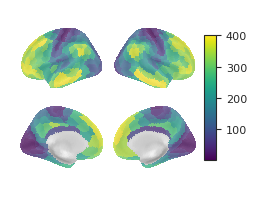

In [3]:
# sa axis
n_parcels = 400

sa_axis = np.load(os.path.join(datadir, 'schaefer{0}_sa-axis.npy'.format(n_parcels)))
sa_axis = sp.stats.rankdata(sa_axis)
lh_annot_file = os.path.join(schaefer_dir, 'fsaverage5', 'lh.Schaefer2018_{0}Parcels_7Networks_order.annot'.format(n_parcels))
rh_annot_file = os.path.join(schaefer_dir, 'fsaverage5', 'rh.Schaefer2018_{0}Parcels_7Networks_order.annot'.format(n_parcels))
fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage5')

f = surface_plot(data=sa_axis,
                 lh_annot_file=lh_annot_file, rh_annot_file=rh_annot_file,
                 fsaverage=fsaverage, order='lr', cmap='viridis')
f.savefig(os.path.join(outdir, 'sa-axis_schaefer{0}.png'.format(n_parcels)), dpi=1000, bbox_inches='tight', pad_inches=0.01)

# Plot: model performance

In [4]:
# data parameters
task = 'PerceptualDecisionMaking-v0'
dt = 100
batch_size = 32
decision = 400
if task == 'PerceptualDecisionMaking-v0':
    seq_len = 22
elif task == 'MultiSensoryIntegration-v0':
    seq_len = 11
elif task == 'ContextDecisionMaking-v0':
    seq_len = 13
seq_len = seq_len + int((decision - 100) / dt)
seq_len_multi = 5
seq_len = seq_len * seq_len_multi
print(seq_len)

# RNN model and training parameters
rnn_model = 'rnn-tanh'
hidden_size = 100
n_runs = 25
n_epochs = 30000
lr = 0.001

# regularization parameters
reg_type = 'l2'
reg_weight = 0.002
mask_weights = True

125


In [5]:
timing = {'fixation': 200, 'stimulus': 1000, 'delay': 0, 'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}

if mask_weights and hidden_size == 50:
    n_io = '9-13'
elif mask_weights and hidden_size == 100:
    n_io = '14-27'
elif mask_weights and hidden_size == 200:
    n_io = '31-52'
else:
    n_io = 'na'

config = {
    'datadir': datadir, 'outdir': outdir,
    'task': task, 'dt': dt, 'seq_len': seq_len, 'batch_size': batch_size,  # data parameters
    'rnn_model': rnn_model, 'hidden_size': hidden_size, 'n_runs': n_runs, 'n_epochs': n_epochs, 'lr': lr, 'mask_weights': mask_weights,  # RNN model and training parameters
    'reg_type': reg_type, 'reg_weight': reg_weight,  # regularization parameters
    'env_kwargs': env_kwargs,
    'n_io': n_io
}

In [6]:
color_palette = sns.color_palette("Set2")
kernel_types = ['sa_axis', None]
kernel_labels = ['bioRNN', 'RNN']

task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-25-30000_wmask-True-14-27_reg-l2-0.002-sa_axis
task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-25-30000_wmask-True-14-27_reg-l2-0.002-None


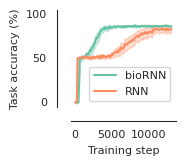

In [7]:
f, ax = plt.subplots(1, 1, figsize=(1.9, 1.7))

for j, kernel_type in enumerate(kernel_types):
    config['kernel_type'] = kernel_type

    # load data
    file_str = get_file_str(config)
    log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
    print(file_str)
    test_accuracy = log_args['test_accuracy'][:, 1:131] * 100

    n_epochs_actual = test_accuracy.shape[1] * 100
    n_logged_epochs = int(n_epochs_actual / 100)
    x_step = int(n_epochs_actual / (n_logged_epochs))
    x = np.arange(x_step, n_epochs_actual + x_step, x_step)
    x2 = np.arange(1, n_epochs_actual)

    # compute mean and ci
    accuracy_mean = test_accuracy.mean(axis=0)
    accuracy_std = test_accuracy.std(axis=0)
    ci = 1.96 * (accuracy_std / np.sqrt(test_accuracy.shape[0]))
    ci_lower = accuracy_mean - ci
    ci_upper = accuracy_mean + ci

    ax.plot(x, accuracy_mean, color=color_palette[j], label=str(kernel_labels[j]))
    ax.fill_between(x, ci_lower, ci_upper, color=color_palette[j], alpha=0.3)

ax.set_xlabel('Training step')
ax.set_ylabel('Task accuracy (%)')
ax.set_ylim([-5, 105])
ax.legend(loc='lower right')
sns.despine(offset=10, trim=False, left=False, right=True, top=True, bottom=False)

f.tight_layout()
plt.show()
file_str = 'accuracy_r{:}_d{:}.svg'.format(reg_weight, decision)
f.savefig(os.path.join(outdir, file_str), dpi=1000, bbox_inches='tight', pad_inches=0.01)

# Plot: model performance vs. degree

In [8]:
# Device configuration
device = torch.device('cpu')

In [9]:
# load data
kernel_type = kernel_types[0]
config['kernel_type'] = kernel_type
file_str = get_file_str(config)
print(file_str)

log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
test_accuracy = log_args['test_accuracy']
n_logged_epochs = test_accuracy.shape[-1]
x_step = int(n_epochs / (n_logged_epochs-1))

checkpoint = torch.load(os.path.join(modeldir, file_str + '.pt'), map_location=device)
hidden_weights = np.zeros((n_runs, n_logged_epochs, hidden_size, hidden_size))
for i, run in enumerate(checkpoint.keys()):
    for j, epoch in enumerate(checkpoint[run].keys()):
        hidden_weights[i, j] = checkpoint[run][epoch]['rnn.weight_hh_l0']
del checkpoint

x_start = 1
test_accuracy = test_accuracy[:, x_start:51] * 100
hidden_weights = hidden_weights[:, x_start:51]
n_logged_epochs = test_accuracy.shape[-1]
n_epochs = (test_accuracy.shape[1] - 1) * 100
x_step = int(n_epochs / (n_logged_epochs-1))

print(test_accuracy.shape)
print(hidden_weights.shape)
print(n_logged_epochs, n_epochs)

task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-25-30000_wmask-True-14-27_reg-l2-0.002-sa_axis
(25, 50)
(25, 50, 100, 100)
50 4900


In [10]:
degree_skewness = np.zeros((n_runs, n_logged_epochs))
degree_max = np.zeros((n_runs, n_logged_epochs))
degree_trimmed_mean = np.zeros((n_runs, n_logged_epochs))
rich_club_coef = np.zeros((n_runs, n_logged_epochs))

for run in tqdm(np.arange(n_runs)):
    for epoch in np.arange(n_logged_epochs):
        A = hidden_weights[run, epoch].copy()
        A = np.abs(A)
        np.fill_diagonal(A, 0)
        thresh = np.quantile(A, q=0.9)
        mask = A > thresh
        A[mask] = 1
        A[~mask] = 0

        _, _, degree = bct.degrees_dir(A)
        x, y = np.unique(degree, return_counts=True)
        degree_skewness[run, epoch] = sp.stats.skew(y)
        degree_max[run, epoch] = np.nanmax(x)

        thresh = np.quantile(degree, q=0.9)
        degree_trimmed_mean[run, epoch] = np.mean(degree[degree>thresh])

        R, Nk, Ek = bct.rich_club_bd(A)
        rich_club_coef[run, epoch] = np.nanmax(R)

100%|██████████| 25/25 [00:01<00:00, 18.36it/s]


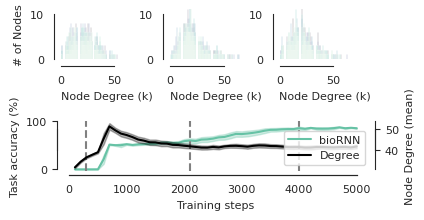

In [11]:
fig_width = 4
fig_height = 5
f = plt.figure(layout=None, figsize=(fig_width, fig_height))
gs = f.add_gridspec(nrows=4, ncols=3, hspace=1.25, wspace=0.2)
ax0_0 = f.add_subplot(gs[0, 0])
ax0_1 = f.add_subplot(gs[0, 1])
ax0_2 = f.add_subplot(gs[0, 2])
ax1 = f.add_subplot(gs[1, :])
ax1_twin = ax1.twinx()

# rows 0 and 2
# indices = [3, 10, 50, 80]
# indices = [5, 15, 25, 45]
indices = np.linspace(3, n_logged_epochs-10, 3).astype(int)
n_indices = len(indices)
color_palette = sns.color_palette("mako", n_colors=n_runs)
ax0_list = [ax0_0, ax0_1, ax0_2]
for run in np.arange(n_runs):
    for epoch in np.arange(n_indices):
        A = hidden_weights[run, indices[epoch]].copy()
        A = np.abs(A)
        np.fill_diagonal(A, 0)
        thresh = np.quantile(A, q=0.9)
        mask = A > thresh
        A[mask] = 1
        A[~mask] = 0

        _, _, degree = bct.degrees_dir(A)
        x, y = np.unique(degree, return_counts=True)
        ax0_list[epoch].bar(x, y, alpha=0.25, color=color_palette[run])
        # ax0_list[epoch].set_title('Epoch: {0}'.format(indices[epoch]*100))
        ax0_list[epoch].set_xlabel("Node Degree (k)")

        if epoch == 0:
            ax0_list[epoch].set_ylabel("# of Nodes")

# set axis limits and despine
for epoch in np.arange(n_indices):
    ax0_list[epoch].set_xlim([0, 85])
    ax0_list[epoch].set_ylim([0, 11])
    sns.despine(offset=5, trim=True, left=False, right=True, top=True, bottom=False, ax=ax0_list[epoch])

# rows 1 and 3
color_palette = sns.color_palette("Set2")
x_step = int(n_epochs / (n_logged_epochs-1))
x = np.arange(x_step, n_epochs + x_step + 1, x_step)

# add accuracy to each plot
accuracy_mean = test_accuracy.mean(axis=0)
accuracy_std = test_accuracy.std(axis=0)
ci = 1.96 * (accuracy_std / np.sqrt(n_runs))
accuracy_ci_lower = accuracy_mean - ci
accuracy_ci_upper = accuracy_mean + ci

ax1.plot(x, accuracy_mean, color=color_palette[0], label='bioRNN')
ax1.fill_between(x, accuracy_ci_lower, accuracy_ci_upper, color=color_palette[0], alpha=0.3)
ax1.set_ylim([-2.5, 100])
ax1.set_ylabel('Task accuracy (%)')
ax1.set_xlabel('Training steps')
for epoch in np.arange(n_indices):
    ax1.axvline(indices[epoch]*100, color='gray', linestyle='--')

# Degree, trimmed mean
y_mean = degree_trimmed_mean.mean(axis=0)
y_std = degree_trimmed_mean.std(axis=0)
ci = 1.96 * (y_std / np.sqrt(n_runs))
ci_lower = y_mean - ci
ci_upper = y_mean + ci

ax1_twin.plot(x, y_mean, color='k', label='Degree')
ax1_twin.fill_between(x, ci_lower, ci_upper, color='k', alpha=0.3)
ax1_twin.set_ylabel('Node Degree (mean)')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1_twin.legend(lines + lines2, labels + labels2, loc='lower right')

# set axis limits and despine
for this_ax in [ax1, ax1_twin]:
    sns.despine(offset=3, trim=True, left=False, right=False, top=True, bottom=False, ax=this_ax)

plt.show()
f.savefig(os.path.join(outdir, 'rich_club.svg'), dpi=1000, bbox_inches='tight', pad_inches=0.01)
f.savefig(os.path.join(outdir, 'rich_club.png'), dpi=1000, bbox_inches='tight', pad_inches=0.01)

# Plot: connectome coupling

In [12]:
# load data
kernel_type = kernel_types[0]
config['kernel_type'] = kernel_type
file_str = get_file_str(config)
print(file_str)

log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
test_accuracy = log_args['test_accuracy']
n_logged_epochs = test_accuracy.shape[-1]
x_step = int(n_epochs / (n_logged_epochs-1))

checkpoint = torch.load(os.path.join(modeldir, file_str + '.pt'), map_location=device)
hidden_weights = np.zeros((n_runs, n_logged_epochs, hidden_size, hidden_size))
for i, run in enumerate(checkpoint.keys()):
    for j, epoch in enumerate(checkpoint[run].keys()):
        hidden_weights[i, j] = checkpoint[run][epoch]['rnn.weight_hh_l0']
del checkpoint

x_start = 1
test_accuracy = test_accuracy[:, x_start:131] * 100
hidden_weights = hidden_weights[:, x_start:131]
n_logged_epochs = test_accuracy.shape[-1]
n_epochs = (test_accuracy.shape[1] - 1) * 100
x_step = int(n_epochs / (n_logged_epochs-1))

print(test_accuracy.shape)
print(hidden_weights.shape)
print(n_logged_epochs, n_epochs)

task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-25-30000_wmask-True-14-27_reg-l2-0.002-sa_axis
(25, 130)
(25, 130, 100, 100)
130 12900


### Connectome weights

In [13]:
tracto_string = 'probabilistic_sift_radius2_count'
n_parcels = int(hidden_size * 2)

A_human = np.load(os.path.join(datadir, tracto_string, '{0}_schaefer{1}-7_A.npy').format('hbn', n_parcels))
A_human = A_human[:hidden_size, :hidden_size, :]
Am_human = np.load(os.path.join(datadir, tracto_string, '{0}_schaefer{1}-7_Am.npy').format('hbn', n_parcels))
Am_human = Am_human[:hidden_size, :hidden_size]

df_hbn = pd.read_csv(os.path.join(datadir, tracto_string,  '{0}_schaefer{1}-7_df.csv').format('hbn', n_parcels), index_col=0)
df_human = df_hbn
df_human = df_human[df_hbn['study_site'] == 'HBN-3']
A_human = A_human[:, :, df_hbn['study_site'] == 'HBN-3']

print(A_human.shape, df_human.shape)
print(df_human['age'].describe())
n_subjects = A_human.shape[-1]

(100, 100, 510) (510, 4)
count    510.000000
mean      11.336514
std        3.364671
min        5.838923
25%        8.647957
50%       10.750113
75%       13.607574
max       21.216746
Name: age, dtype: float64


# Stats

In [14]:
from numba import njit

@njit
def get_mean(x):
    n = len(x)
    m = np.empty(n)
    for i in range(n):
        m[i] = x[i].mean()
    return m

@njit
def get_std(x):
    n = len(x)
    s = np.empty(n)
    for i in range(n):
        s[i] = x[i].std()
    return s

@njit
def get_corr_fast(x, y):
    ''' Correlation '''
    n, k = x.shape
    m, k = y.shape

    mu_a = get_mean(x)
    mu_b = get_mean(y)
    sig_a = get_std(x)
    sig_b = get_std(y)

    corr_coef = np.empty((n, m))

    for i in range(n):
        for j in range(m):
            corr_coef[i, j] = (x[i] - mu_a[i]) @ (y[j] - mu_b[j]) / k / sig_a[i] / sig_b[j]

    return corr_coef

In [15]:
df_human['age_group'] = np.zeros(n_subjects)
n_quantiles = 3
quantiles = np.linspace(0, 1, n_quantiles+1)[1:]
print(quantiles)
for i, q in enumerate(quantiles):
    thresh = np.quantile(df_human['age'], q=q)
    if i == 0:
        mask = df_human['age'] <= thresh
    else:
        mask = np.logical_and(df_human['age'] <= thresh, df_human['age'] > previous_thresh)
    df_human.loc[mask, 'age_group'] = i
    previous_thresh = thresh

print(df_human.groupby('age_group')['age'].count())
print(df_human.groupby('age_group')['age'].mean())

[0.33333333 0.66666667 1.        ]
age_group
0.0    170
1.0    170
2.0    170
Name: age, dtype: int64
age_group
0.0     7.925278
1.0    10.729237
2.0    15.355028
Name: age, dtype: float64


/tmp/ipykernel_44725/2329848731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_human['age_group'] = np.zeros(n_subjects)


In [16]:
thresh = np.quantile(Am_human, q=0.8)
mask = Am_human > thresh
Am_human_thresh = Am_human.copy()
Am_human_thresh[mask] = 1
Am_human_thresh[~mask] = 0
np.fill_diagonal(Am_human_thresh, 0)

# f, ax = plt.subplots(1, 2, figsize=(10, 5))
# sns.heatmap(Am_human, ax=ax[0], square=True)
# sns.heatmap(Am_human_thresh, ax=ax[1], square=True)

In [17]:
# weight_mask = Am_human > 0
weight_mask = Am_human_thresh > 0
# weight_mask = Am_human[masks['bystanders_bystanders']] > 0
n_features = np.sum(weight_mask)
print(n_features)
rnn_features = np.zeros((n_runs, n_logged_epochs, n_features))
for run in tqdm(np.arange(n_runs)):
    for epoch in np.arange(n_logged_epochs):
        A = np.abs(hidden_weights[run, epoch]).copy()
        A = (A + A.T) / 2
        # A = A[masks['bystanders_bystanders']]
        A = A[weight_mask]
        rnn_features[run, epoch, :] = A
        rnn_features[run, epoch, :] = sp.stats.rankdata(rnn_features[run, epoch, :])

human_features = np.zeros((n_subjects, n_features))
for subj in np.arange(n_subjects):
    A = A_human[:, :, subj].copy()
    # A = A[masks['bystanders_bystanders']]
    A = A[weight_mask]
    human_features[subj, :] = A
    human_features[subj, :] = sp.stats.rankdata(human_features[subj, :])


feature_corr = np.zeros((n_runs, n_logged_epochs, n_subjects))
for run in tqdm(np.arange(n_runs)):
    feature_corr[run] = get_corr_fast(rnn_features[run, :, :], human_features)
feature_corr_mean = np.mean(feature_corr, axis=0)

feature_corr_mean_group = np.zeros((n_logged_epochs, n_quantiles))
for group in np.arange(n_quantiles):
    feature_corr_mean_group[:, group] = np.mean(feature_corr_mean[:, df_human['age_group'] == group], axis=1)

print(rnn_features.shape, human_features.shape)
print(feature_corr.shape, feature_corr_mean_group.shape)

1904


100%|██████████| 25/25 [00:01<00:00, 16.57it/s]

(25, 130, 1904) (510, 1904)
(25, 130, 510) (130, 3)


In [18]:
age_corr = np.zeros((n_runs, n_logged_epochs))
for run in tqdm(np.arange(n_runs)):
    for epoch in np.arange(n_logged_epochs):
        age_corr[run, epoch] = sp.stats.spearmanr(df_human['age'], feature_corr[run, epoch])[0]

age_corr_mean = np.zeros(n_logged_epochs)
for epoch in tqdm(np.arange(n_logged_epochs)):
    age_corr_mean[epoch] = sp.stats.spearmanr(df_human['age'], feature_corr_mean[epoch])[0]

print(age_corr.shape, age_corr_mean.shape)

100%|██████████| 130/130 [00:00<00:00, 5485.62it/s]

(25, 130) (130,)


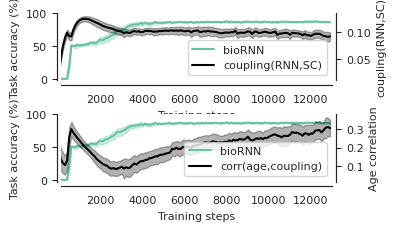

In [20]:
fig_width = 3.5
fig_height = 3.5
f = plt.figure(layout=None, figsize=(fig_width, fig_height))
cbar_width = 2.5
column_width = (100 - cbar_width) / 4
gs = f.add_gridspec(nrows=3, ncols=4, hspace=0.5, wspace=0.75)
ax1 = f.add_subplot(gs[0, :])
ax1_twin = ax1.twinx()
ax2 = f.add_subplot(gs[1, :])
ax2_twin = ax2.twinx()

x = np.arange(0, n_epochs + x_step, x_step)
# x = np.arange(x_step, n_epochs + x_step + 1, x_step)

# row 1, 2
color_palette = sns.color_palette("Set2")
# add accuracy to both
accuracy_mean = test_accuracy.mean(axis=0)
accuracy_std = test_accuracy.std(axis=0)
ci = 1.96 * (accuracy_std / np.sqrt(n_runs))
accuracy_ci_lower = accuracy_mean - ci
accuracy_ci_upper = accuracy_mean + ci
for this_ax in [ax1, ax2]:
    this_ax.plot(x, accuracy_mean, color=color_palette[0], label='bioRNN')
    this_ax.fill_between(x, accuracy_ci_lower, accuracy_ci_upper, color=color_palette[0], alpha=0.3)
    this_ax.set_ylim([-2.5, 100])
    this_ax.set_xlim([x_start*100, (n_logged_epochs+x_start-1)*100])
    this_ax.set_ylabel('Task accuracy (%)')
    this_ax.set_xlabel('Training steps')

# row 1
coupling_mean = feature_corr.mean(axis=-1).mean(axis=0)
coupling_std = feature_corr.mean(axis=-1).std(axis=0)
ci = 1.96 * (coupling_std / np.sqrt(n_runs))
ax1_twin.plot(x, coupling_mean, color='k', label='coupling(RNN,SC)')
ax1_twin.fill_between(x, coupling_mean - ci, coupling_mean + ci, color='k', alpha=0.3)
ax1_twin.set_ylabel('coupling(RNN,SC)')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1_twin.legend(lines + lines2, labels + labels2, loc='lower right')

# row 2
age_corr_std = age_corr.std(axis=0)
ci = 1.96 * (age_corr_std / np.sqrt(n_runs))
ax2_twin.plot(x, age_corr_mean, color='k', label='corr(age,coupling)')
ax2_twin.fill_between(x, age_corr_mean - ci, age_corr_mean + ci, color='k', alpha=0.3)
ax2_twin.set_ylabel('Age correlation')
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2_twin.legend(lines + lines2, labels + labels2, loc='lower right')

for this_ax in [ax1, ax1_twin, ax2, ax2_twin]:
    sns.despine(offset=3, trim=False, left=False, right=False, top=True, bottom=False, ax=this_ax)

plt.show()
f.savefig(os.path.join(outdir, 'coupling(rnn,sc).svg'), dpi=1000, bbox_inches='tight', pad_inches=0.01)